In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder
#1
print("URK22CS1194")
df = pd.read_csv("B5_Stores1b.csv")
df.iloc[0:2,:]
df["Gender"].unique()


URK22CS1194


array(['Female', 'Male'], dtype=object)

In [ ]:
#2
print("URK22CS1194")
missing_percentage = df.isnull().sum() / len(df) * 100
print("Missing Values Percentage:\n", missing_percentage)


URK22CS1194
Missing Values Percentage:
 Branch            7.843137
City              0.000000
Customer          0.000000
Gender            0.000000
Product line     35.294118
Unit_price        0.000000
Quantity          0.000000
Tax               0.000000
Total             0.000000
Payment           0.000000
cogs              0.000000
Rating            0.000000
Age               0.000000
Quarterly_Tax     7.843137
Price             0.000000
dtype: float64


In [ ]:
#3
print("URK22CS1194")

temp_df = df.copy(deep=True)

numeric_cols = temp_df.select_dtypes(include=['number']).columns

for col in numeric_cols:
    if missing_percentage[col] < 10:
        temp_df[col].fillna(temp_df[col].mean(), inplace=True)

print("DataFrame after filling missing values with mean:\n", temp_df.head())


URK22CS1194
DataFrame after filling missing values with mean:
   Branch       City Customer  Gender            Product line  Unit_price  \
0      A     Yangon   Member  Female       Health and beauty       74.69   
1      C  Naypyitaw   Normal  Female  Electronic accessories       15.28   
2      A     Yangon   Normal    Male      Home and lifestyle       46.33   
3      A     Yangon   Member    Male       Health and beauty       58.22   
4      A     Yangon   Normal    Male       Sports and travel       86.31   

   Quantity      Tax     Total      Payment    cogs  Rating  Age  \
0         7  26.1415  548.9715      Ewallet  522.83     9.1   23   
1         5   3.8200   80.2200         Cash   76.40     9.6   23   
2         7  16.2155  340.5255  Credit card  324.31     7.4   24   
3         8  23.2880  489.0480      Ewallet  465.76     8.4   26   
4        60  30.2085  634.3785      Ewallet  604.17     5.3   30   

   Quarterly_Tax  Price  
0          210.0   7469  
1          210.0   

<ipython-input-30-77477813bd16>:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  temp_df[col].fillna(temp_df[col].mean(), inplace=True)


In [ ]:
#4
print("URK22CS1194")
numeric_cols = temp_df.select_dtypes(include=['number']).columns

temp_df[numeric_cols] = temp_df[numeric_cols].infer_objects(copy=False)

temp_df[numeric_cols] = temp_df[numeric_cols].interpolate(method='nearest')

print("DataFrame after interpolation:\n", temp_df.head())


URK22CS1194
DataFrame after interpolation:
   Branch       City Customer  Gender            Product line  Unit_price  \
0      A     Yangon   Member  Female       Health and beauty       74.69   
1      C  Naypyitaw   Normal  Female  Electronic accessories       15.28   
2      A     Yangon   Normal    Male      Home and lifestyle       46.33   
3      A     Yangon   Member    Male       Health and beauty       58.22   
4      A     Yangon   Normal    Male       Sports and travel       86.31   

   Quantity      Tax     Total      Payment    cogs  Rating  Age  \
0         7  26.1415  548.9715      Ewallet  522.83     9.1   23   
1         5   3.8200   80.2200         Cash   76.40     9.6   23   
2         7  16.2155  340.5255  Credit card  324.31     7.4   24   
3         8  23.2880  489.0480      Ewallet  465.76     8.4   26   
4        60  30.2085  634.3785      Ewallet  604.17     5.3   30   

   Quarterly_Tax  Price  
0          210.0   7469  
1          210.0   1528  
2          1

In [ ]:
#5
print("URK22CS1194")
categorical_cols = temp_df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    if missing_percentage[col] < 10:
        temp_df[col].fillna(temp_df[col].mode()[0], inplace=True)

print("DataFrame after filling missing categorical values with mode:\n", temp_df.head())


URK22CS1194
DataFrame after filling missing categorical values with mode:
   Branch       City Customer  Gender            Product line  Unit_price  \
0      A     Yangon   Member  Female       Health and beauty       74.69   
1      C  Naypyitaw   Normal  Female  Electronic accessories       15.28   
2      A     Yangon   Normal    Male      Home and lifestyle       46.33   
3      A     Yangon   Member    Male       Health and beauty       58.22   
4      A     Yangon   Normal    Male       Sports and travel       86.31   

   Quantity      Tax     Total      Payment    cogs  Rating  Age  \
0         7  26.1415  548.9715      Ewallet  522.83     9.1   23   
1         5   3.8200   80.2200         Cash   76.40     9.6   23   
2         7  16.2155  340.5255  Credit card  324.31     7.4   24   
3         8  23.2880  489.0480      Ewallet  465.76     8.4   26   
4        60  30.2085  634.3785      Ewallet  604.17     5.3   30   

   Quarterly_Tax  Price  
0          210.0   7469  
1      

<ipython-input-35-4c87b9b91389>:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  temp_df[col].fillna(temp_df[col].mode()[0], inplace=True)


KeyError: 0

In [ ]:
#6
print("URK22CS1194")
drop_cols = missing_percentage[missing_percentage > 10].index
temp_df.drop(columns=drop_cols, inplace=True)

print("Data size after dropping columns:", temp_df.shape)
print(temp_df.head())


URK22CS1194
Data size after dropping columns: (51, 14)
  Branch       City Customer  Gender  Unit_price  Quantity      Tax     Total  \
0      A     Yangon   Member  Female       74.69         7  26.1415  548.9715   
1      C  Naypyitaw   Normal  Female       15.28         5   3.8200   80.2200   
2      A     Yangon   Normal    Male       46.33         7  16.2155  340.5255   
3      A     Yangon   Member    Male       58.22         8  23.2880  489.0480   
4      A     Yangon   Normal    Male       86.31        60  30.2085  634.3785   

       Payment    cogs  Rating  Age  Quarterly_Tax  Price  
0      Ewallet  522.83     9.1   23          210.0   7469  
1         Cash   76.40     9.6   23          210.0   1528  
2  Credit card  324.31     7.4   24          124.0   4633  
3      Ewallet  465.76     8.4   26          210.0   5822  
4      Ewallet  604.17     5.3   30          210.0   8631  


In [ ]:
#7
print("URK22CS1194")
z_scores = zscore(temp_df['Quantity'])
outliers = np.abs(z_scores) > 3
temp_df = temp_df[~outliers]
print("Data size after dropping outliers:", temp_df.shape)
print(temp_df.head())


URK22CS1194
Data size after dropping outliers: (47, 14)
  Branch       City Customer  Gender  Unit_price  Quantity      Tax     Total  \
0      A     Yangon   Member  Female       74.69         7  26.1415  548.9715   
1      C  Naypyitaw   Normal  Female       15.28         5   3.8200   80.2200   
2      A     Yangon   Normal    Male       46.33         7  16.2155  340.5255   
3      A     Yangon   Member    Male       58.22         8  23.2880  489.0480   
5      C  Naypyitaw   Normal    Male       85.39         7  29.8865  627.6165   

       Payment    cogs  Rating  Age  Quarterly_Tax  Price  
0      Ewallet  522.83     9.1   23          210.0   7469  
1         Cash   76.40     9.6   23          210.0   1528  
2  Credit card  324.31     7.4   24          124.0   4633  
3      Ewallet  465.76     8.4   26          210.0   5822  
5      Ewallet  597.73     4.1   32          210.0   8539  


In [ ]:
#8
print("URK22CS1194")
duplicate_percentage = (temp_df.duplicated().sum() / len(temp_df)) * 100
print(f"% of Duplicate Rows: {duplicate_percentage:.2f}%")


URK22CS1194
% of Duplicate Rows: 4.26%


In [ ]:
#9
print("URK22CS1194")
corrected_columns = [col for col in ['Customer', 'Product line', 'Age', 'Gender'] if col in temp_df.columns]
duplicate_percentage_specific = (temp_df.duplicated(subset=corrected_columns).sum() / len(temp_df)) * 100
temp_df.drop_duplicates(subset=corrected_columns, inplace=True)
print(f"% of Duplicate Rows (specific columns): {duplicate_percentage_specific:.2f}%")
print("Data size after dropping specific duplicates:", temp_df.shape)
print(temp_df.head())



URK22CS1194
% of Duplicate Rows (specific columns): 42.55%
Data size after dropping specific duplicates: (27, 14)
  Branch       City Customer  Gender  Unit_price  Quantity      Tax     Total  \
0      A     Yangon   Member  Female       74.69         7  26.1415  548.9715   
1      C  Naypyitaw   Normal  Female       15.28         5   3.8200   80.2200   
2      A     Yangon   Normal    Male       46.33         7  16.2155  340.5255   
3      A     Yangon   Member    Male       58.22         8  23.2880  489.0480   
5      C  Naypyitaw   Normal    Male       85.39         7  29.8865  627.6165   

       Payment    cogs  Rating  Age  Quarterly_Tax  Price  
0      Ewallet  522.83     9.1   23          210.0   7469  
1         Cash   76.40     9.6   23          210.0   1528  
2  Credit card  324.31     7.4   24          124.0   4633  
3      Ewallet  465.76     8.4   26          210.0   5822  
5      Ewallet  597.73     4.1   32          210.0   8539  


<ipython-input-9-c81260218b5d>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp_df.drop_duplicates(subset=corrected_columns, inplace=True)


URK22CS1194


<ipython-input-10-3a510267d467>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp_df['Age_MinMax'] = scaler.fit_transform(temp_df[['Age']])


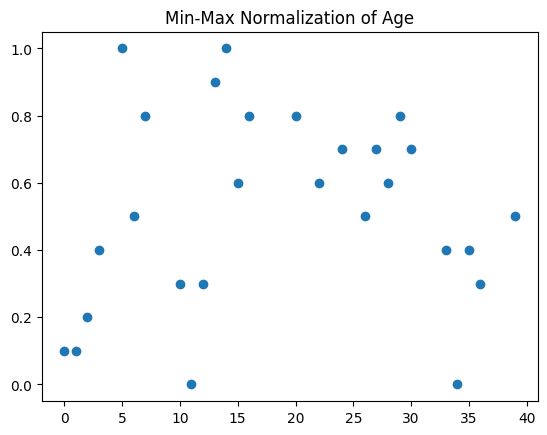

   Age  Age_MinMax
0   23         0.1
1   23         0.1
2   24         0.2
3   26         0.4
5   32         1.0


In [ ]:
#10
print("URK22CS1194")
scaler = MinMaxScaler()
temp_df['Age_MinMax'] = scaler.fit_transform(temp_df[['Age']])
plt.scatter(temp_df.index, temp_df['Age_MinMax'])
plt.title("Min-Max Normalization of Age")
plt.show()

print(temp_df[['Age', 'Age_MinMax']].head())


URK22CS1194


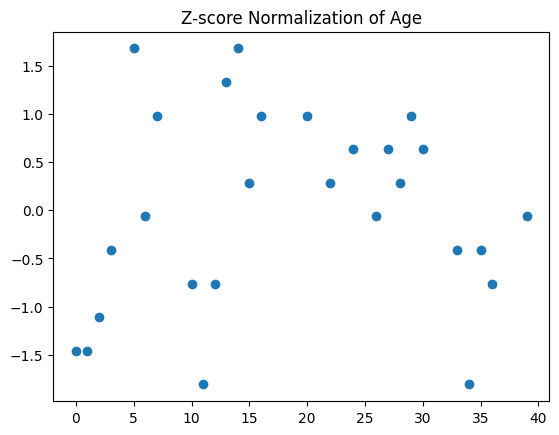

   Age  Age_Zscore
0   23   -1.459310
1   23   -1.459310
2   24   -1.110625
3   26   -0.413256
5   32    1.678852


In [ ]:
#11
print("URK22CS1194")
scaler = StandardScaler()
temp_df['Age_Zscore'] = scaler.fit_transform(temp_df[['Age']])


plt.scatter(temp_df.index, temp_df['Age_Zscore'])
plt.title("Z-score Normalization of Age")
plt.show()

print(temp_df[['Age', 'Age_Zscore']].head())


In [ ]:
#12
print("URK22CS1194")
le = LabelEncoder()
temp_df['Payment_LabelEncoded'] = le.fit_transform(temp_df['Payment'])

print(temp_df[['Payment', 'Payment_LabelEncoded']].head())


URK22CS1194
       Payment  Payment_LabelEncoded
0      Ewallet                     2
1         Cash                     0
2  Credit card                     1
3      Ewallet                     2
5      Ewallet                     2


In [ ]:
#13
print("URK22CS1194")
payment_dummies = pd.get_dummies(temp_df['Payment'], prefix='Payment')
temp_df = pd.concat([temp_df, payment_dummies], axis=1)ee

print(temp_df.head())


URK22CS1194
  Branch       City Customer  Gender  Unit_price  Quantity      Tax     Total  \
0      A     Yangon   Member  Female       74.69         7  26.1415  548.9715   
1      C  Naypyitaw   Normal  Female       15.28         5   3.8200   80.2200   
2      A     Yangon   Normal    Male       46.33         7  16.2155  340.5255   
3      A     Yangon   Member    Male       58.22         8  23.2880  489.0480   
5      C  Naypyitaw   Normal    Male       85.39         7  29.8865  627.6165   

       Payment    cogs  Rating  Age  Quarterly_Tax  Price  Age_MinMax  \
0      Ewallet  522.83     9.1   23          210.0   7469         0.1   
1         Cash   76.40     9.6   23          210.0   1528         0.1   
2  Credit card  324.31     7.4   24          124.0   4633         0.2   
3      Ewallet  465.76     8.4   26          210.0   5822         0.4   
5      Ewallet  597.73     4.1   32          210.0   8539         1.0   

   Age_Zscore  Payment_LabelEncoded  Payment_Cash  Payment_Cre